In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
tsla = pd.read_csv("../data/processed/TSLA_cleaned.csv", index_col=0, parse_dates=True)
bnd = pd.read_csv("../data/processed/BND_cleaned.csv", index_col=0, parse_dates=True)
spy = pd.read_csv("../data/processed/SPY_cleaned.csv", index_col=0, parse_dates=True)

prices = pd.DataFrame({
    "TSLA": tsla["Adj Close"],
    "BND": bnd["Adj Close"],
    "SPY": spy["Adj Close"]
}).dropna()

daily_returns = prices.pct_change().dropna()

daily_returns.head()

,TSLA,BND,SPY
Date,,,
2015-01-05,-0.042041,0.002904,-0.018060
2015-01-06,0.005664,0.002896,-0.009419
2015-01-07,-0.001562,0.000601,0.012461
2015-01-08,-0.001564,-0.001562,0.017745
2015-01-09,-0.018802,0.001686,-0.008013


In [3]:
backtest_returns = daily_returns["2025-01-01":"2026-01-01"]

backtest_returns.head()

,TSLA,BND,SPY
Date,,,
2025-01-02,-0.060816,0.000417,-0.002457
2025-01-03,0.082156,-0.001251,0.012503
2025-01-06,0.001486,-0.000974,0.005761
2025-01-07,-0.040603,-0.003482,-0.011304
2025-01-08,0.001471,0.001118,0.001461


In [4]:
print(backtest_returns.index.min())
print(backtest_returns.index.max())
print(backtest_returns.shape)

2025-01-02 00:00:00
2025-12-31 00:00:00
(250, 3)


In [5]:
weights_df = pd.read_csv("../data/processed/recommended_portfolio_weights.csv")

weights_df

,Asset,Weight
0,TSLA,0.000699
1,BND,0.121162
2,SPY,0.878139


In [6]:
strategy_weights = weights_df.set_index("Asset")["Weight"]

strategy_weights

Asset
TSLA    0.000699
BND     0.121162
SPY     0.878139
Name: Weight, dtype: float64

In [7]:
strategy_weights = strategy_weights[["TSLA", "BND", "SPY"]]

strategy_weights

Asset
TSLA    0.000699
BND     0.121162
SPY     0.878139
Name: Weight, dtype: float64

In [8]:
benchmark_weights = pd.Series({
    "TSLA": 0.0,
    "BND": 0.4,
    "SPY": 0.6
})

benchmark_weights

TSLA    0.0
BND     0.4
SPY     0.6
dtype: float64

In [9]:
strategy_daily_returns = backtest_returns.dot(strategy_weights)

benchmark_daily_returns = backtest_returns.dot(benchmark_weights)

strategy_daily_returns.head()

Date
2025-01-02   -0.002149
2025-01-03    0.010885
2025-01-06    0.004942
2025-01-07   -0.010377
2025-01-08    0.001419
dtype: float64

In [10]:
strategy_cumulative = (1 + strategy_daily_returns).cumprod()
benchmark_cumulative = (1 + benchmark_daily_returns).cumprod()

strategy_cumulative.head()

Date
2025-01-02    0.997851
2025-01-03    1.008713
2025-01-06    1.013697
2025-01-07    1.003178
2025-01-08    1.004602
dtype: float64

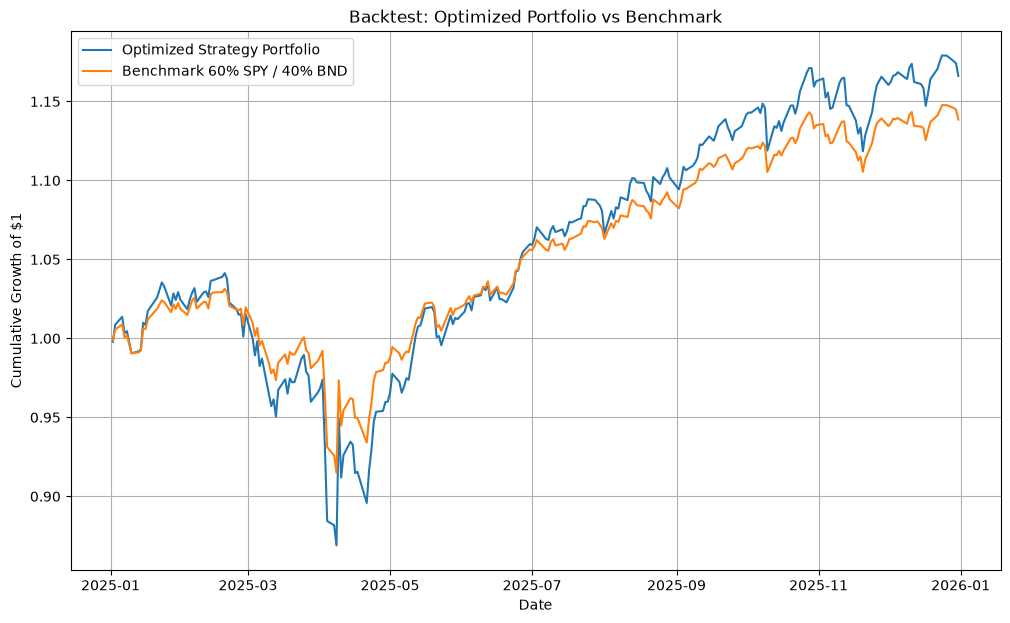

In [11]:
os.makedirs("../reports/figures", exist_ok=True)

plt.figure(figsize=(12, 7))

plt.plot(strategy_cumulative.index, strategy_cumulative, label="Optimized Strategy Portfolio")
plt.plot(benchmark_cumulative.index, benchmark_cumulative, label="Benchmark 60% SPY / 40% BND")

plt.title("Backtest: Optimized Portfolio vs Benchmark")
plt.xlabel("Date")
plt.ylabel("Cumulative Growth of $1")
plt.legend()
plt.grid(True)

plt.savefig("../reports/figures/backtest_strategy_vs_benchmark.png", dpi=300, bbox_inches="tight")
plt.show()

In [12]:
def calculate_performance_metrics(returns, risk_free_rate=0.02):
    total_return = (1 + returns).prod() - 1
    
    number_of_days = len(returns)
    annualized_return = (1 + total_return) ** (252 / number_of_days) - 1
    
    annualized_volatility = returns.std() * np.sqrt(252)
    
    sharpe_ratio = (annualized_return - risk_free_rate) / annualized_volatility
    
    cumulative_returns = (1 + returns).cumprod()
    running_max = cumulative_returns.cummax()
    drawdown = (cumulative_returns - running_max) / running_max
    max_drawdown = drawdown.min()
    
    return {
        "Total Return": total_return,
        "Annualized Return": annualized_return,
        "Annualized Volatility": annualized_volatility,
        "Sharpe Ratio": sharpe_ratio,
        "Maximum Drawdown": max_drawdown
    }

In [13]:
strategy_metrics = calculate_performance_metrics(strategy_daily_returns)
benchmark_metrics = calculate_performance_metrics(benchmark_daily_returns)

performance_table = pd.DataFrame([
    {"Portfolio": "Optimized Strategy", **strategy_metrics},
    {"Portfolio": "Benchmark 60% SPY / 40% BND", **benchmark_metrics}
])

performance_table

,Portfolio,Total Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Maximum Drawdown
0,Optimized Strategy,0.166141,0.167576,0.171988,0.858058,-0.165585
1,Benchmark 60% SPY / 40% BND,0.138525,0.139707,0.119825,0.999015,-0.112888


In [15]:
import os

os.makedirs("data/processed", exist_ok=True)

performance_table.to_csv(
    "data/processed/backtest_performance_metrics.csv",
    index=False
)

In [16]:
performance_table.to_csv("../data/processed/backtest_performance_metrics.csv", index=False)

In [17]:
strategy_total_return = performance_table.loc[
    performance_table["Portfolio"] == "Optimized Strategy",
    "Total Return"
].values[0]

benchmark_total_return = performance_table.loc[
    performance_table["Portfolio"] == "Benchmark 60% SPY / 40% BND",
    "Total Return"
].values[0]

if strategy_total_return > benchmark_total_return:
    print("The optimized strategy outperformed the benchmark based on total return.")
else:
    print("The optimized strategy did not outperform the benchmark based on total return.")

The optimized strategy outperformed the benchmark based on total return.


## Backtesting Conclusion

The backtest compared the optimized portfolio from Task 4 against a simple benchmark portfolio of 60% SPY and 40% BND. The purpose was to test whether the model-driven portfolio would have performed better during the selected historical period.

If the optimized portfolio outperformed the benchmark, this suggests that the forecast-driven allocation may have added value during the backtesting period. However, if it underperformed, it suggests that the forecast-driven strategy may not be strong enough on its own and should be improved before being used in real investment decisions.

This backtest has limitations. It uses a single historical period and assumes static portfolio weights. It also does not include transaction costs, taxes, slippage, or real-world market constraints. Therefore, the result should be treated as an initial validation rather than final proof of strategy performance.